Flow to perform clustering on a dataset:

Step1:Understanding the business problem
Step2:Data Collection
Step3:Exploratory Data Analysis
Step4:Data PreProcessing
Step5:Future Selection(nothing but selecting required columns)
Step6:Selecting suitable clustering algorithm
Step7:Datermining the no of clusters
Step8:Clustering the data
Step9:Evaluating the clustering results
Step10:Interpreting the results and making business decisions

In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv("D:\\Data Science\\student_synthetic_dataset_10000.csv")
#print(df)
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           10000 non-null  int64
 1   income        10000 non-null  int64
 2   budget        10000 non-null  int64
 3   phn_no        9987 non-null   str  
 4   mail          9977 non-null   str  
 5   rented_house  10000 non-null  str  
 6   insurance     10000 non-null  str  
 7   occupation    10000 non-null  str  
dtypes: int64(3), str(5)
memory usage: 625.1 KB


In [2]:
#check null values
df.isna().sum()

age              0
income           0
budget           0
phn_no          13
mail            23
rented_house     0
insurance        0
occupation       0
dtype: int64

In [3]:
df.head()

,age,income,budget,phn_no,mail,rented_house,insurance,occupation
0,56,56529,3469,568-649-9918,lee.white44@example.com,no,no,analyst
1,46,23904,1462,630-865-6018,devon.moore264@example.com,no,no,driver
2,32,109301,2816,752-116-7750,dakota.smith249@example.com,yes,yes,teacher
3,60,77370,3588,845-400-1087,NaN,no,yes,sales
4,25,81819,2598,909-662-2268,lee.smith23@example.com,no,no,healthcare


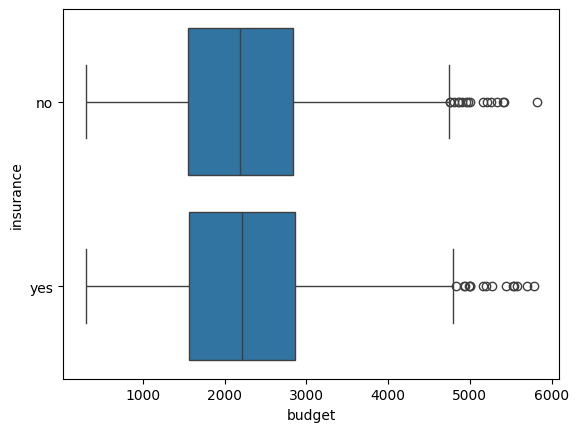

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="budget", y="insurance", data=df)
plt.show()

In [9]:
df.dropna(subset=["phn_no"], inplace=True)
df.shape

(9987, 8)

In [18]:
df["mail"] = df["mail"].fillna('unknown')

In [20]:
df["mail"].value_counts()

mail
unknown                        23
jordan.patel970@example.com     3
jordan.smith655@example.com     3
lee.anderson1@example.com       3
lee.smith23@example.com         2
                               ..
jordan.patel943@example.com     1
jordan.lewis544@example.com     1
devon.davis36@example.com       1
alex.lewis689@example.com       1
aidan.patel437@example.com      1
Name: count, Length: 9810, dtype: int64

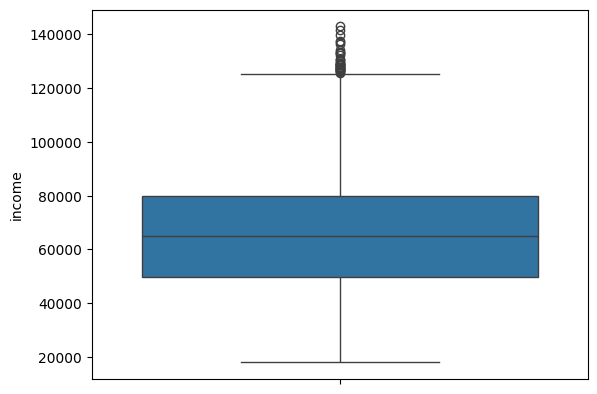

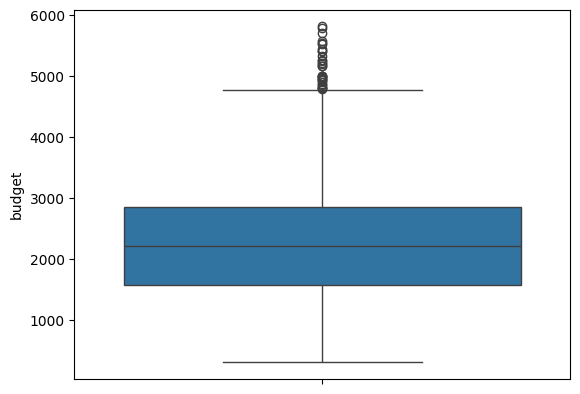

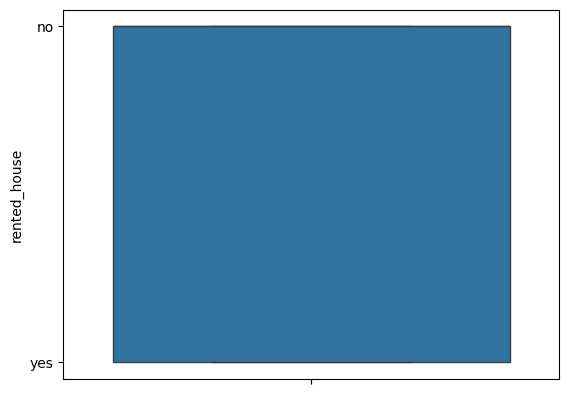

In [24]:
sns.boxplot(data=df,y='income')
plt.show()
sns.boxplot(data=df,y='budget')
plt.show()
sns.boxplot(data=df,y='rented_house')
plt.show()

In [25]:
df.describe()

,age,income,budget
count,9987.000000,9987.000000,9987.000000
mean,41.556123,64940.552919,2216.791829
std,13.747207,21930.401449,932.136779
min,18.000000,18000.000000,300.000000
25%,30.000000,49659.500000,1563.000000
50%,42.000000,65003.000000,2203.000000
75%,53.000000,80007.500000,2849.000000
max,65.000000,142969.000000,5816.000000


In [92]:
print(df)

      age  income  budget        phn_no                         mail  \
0      56   56529    3469  568-649-9918      lee.white44@example.com   
1      46   23904    1462  630-865-6018   devon.moore264@example.com   
2      32  109301    2816  752-116-7750  dakota.smith249@example.com   
3      60   77370    3588  845-400-1087                      unknown   
4      25   81819    2598  909-662-2268      lee.smith23@example.com   
...   ...     ...     ...           ...                          ...   
9995   34   75220    2820  308-110-8518  jordan.patel943@example.com   
9996   47   80952     701  639-955-1108  jordan.lewis544@example.com   
9997   56   71683    3429  123-772-5594    devon.davis36@example.com   
9998   24   47405    2102  471-264-7540    alex.lewis689@example.com   
9999   44  102696    1348  371-723-8594   aidan.patel437@example.com   

      rented_house  insurance  occupation  
0                0          0           1  
1                0          0           6  
2  

In [ ]:
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
km_df=KMeans(n_clusters=4,random_state=50)
km_df.fit(df[["income","budget","rented_house","insurance","occupation"]])
plt.scatter(df["income"],df["budget"],df["insurance"],c=km_df.labels_,cmap="rainbow")
plt.show()
print(df)

      age  income  budget        phn_no                         mail  \
0      56   56529    3469  568-649-9918      lee.white44@example.com   
1      46   23904    1462  630-865-6018   devon.moore264@example.com   
2      32  109301    2816  752-116-7750  dakota.smith249@example.com   
3      60   77370    3588  845-400-1087                          NaN   
4      25   81819    2598  909-662-2268      lee.smith23@example.com   
...   ...     ...     ...           ...                          ...   
9995   34   75220    2820  308-110-8518  jordan.patel943@example.com   
9996   47   80952     701  639-955-1108  jordan.lewis544@example.com   
9997   56   71683    3429  123-772-5594    devon.davis36@example.com   
9998   24   47405    2102  471-264-7540    alex.lewis689@example.com   
9999   44  102696    1348  371-723-8594   aidan.patel437@example.com   

     rented_house insurance  occupation  
0              no        no     analyst  
1              no        no      driver  
2        

In [43]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
rh = ohe.fit_transform(df[["rented_house"]])
rh = pd.DataFrame(rh, columns=ohe.get_feature_names_out(['rented_house']))
df=pd.concat([df,rh],axis=1)
print(df)

      age  income  budget        phn_no  mail  rented_house  insurance  \
0      56   56529    3469  568-649-9918   1.0           0.0        1.0   
1      46   23904    1462  630-865-6018   1.0           0.0        1.0   
2      32  109301    2816  752-116-7750   1.0           1.0        0.0   
3      60   77370    3588  845-400-1087   1.0           0.0        0.0   
4      25   81819    2598  909-662-2268   1.0           0.0        1.0   
...   ...     ...     ...           ...   ...           ...        ...   
9995   34   75220    2820  308-110-8518   1.0           1.0        1.0   
9996   47   80952     701  639-955-1108   1.0           0.0        0.0   
9997   56   71683    3429  123-772-5594   1.0           1.0        1.0   
9998   24   47405    2102  471-264-7540   1.0           0.0        0.0   
9999   44  102696    1348  371-723-8594   1.0           0.0        1.0   

      occupation  rented_house_0.0  rented_house_1.0  rented_house_0.0  \
0            1.0               1.0   

In [46]:
insu = ohe.fit_transform(df[["insurance"]])
insu=pd.DataFrame(insu, columns=ohe.get_feature_names_out(["insurance"]))
df=pd.concat([df,insu],axis=1)
print(insu)
print(df)

      insurance_0.0  insurance_1.0
0               0.0            1.0
1               0.0            1.0
2               1.0            0.0
3               1.0            0.0
4               0.0            1.0
...             ...            ...
9995            0.0            1.0
9996            1.0            0.0
9997            0.0            1.0
9998            1.0            0.0
9999            0.0            1.0

[10000 rows x 2 columns]
      age  income  budget        phn_no  mail  rented_house  insurance  \
0      56   56529    3469  568-649-9918   1.0           0.0        1.0   
1      46   23904    1462  630-865-6018   1.0           0.0        1.0   
2      32  109301    2816  752-116-7750   1.0           1.0        0.0   
3      60   77370    3588  845-400-1087   1.0           0.0        0.0   
4      25   81819    2598  909-662-2268   1.0           0.0        1.0   
...   ...     ...     ...           ...   ...           ...        ...   
9995   34   75220    2820  308-110-8

In [51]:
ohe = OneHotEncoder(sparse_output=False)
occ = ohe.fit_transform(df[["occupation"]])
occ = pd.DataFrame(occ, columns=ohe.get_feature_names_out(["occupation"]))
print(occ)
df=pd.concat([df,occ],axis=1)
df.head()

      occupation_0.0  occupation_1.0
0                0.0             1.0
1                0.0             1.0
2                0.0             1.0
3                0.0             1.0
4                0.0             1.0
...              ...             ...
9995             0.0             1.0
9996             0.0             1.0
9997             0.0             1.0
9998             0.0             1.0
9999             0.0             1.0

[10000 rows x 2 columns]


,age,income,budget,phn_no,mail,rented_house,insurance,occupation,rented_house_0.0,rented_house_1.0,...,insurance_0.0,insurance_1.0,insurance_0.0,insurance_1.0,occupation_0.0,occupation_1.0,occupation_0.0,occupation_1.0,occupation_0.0,occupation_1.0
0,56,56529,3469,568-649-9918,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,46,23904,1462,630-865-6018,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,32,109301,2816,752-116-7750,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,60,77370,3588,845-400-1087,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,25,81819,2598,909-662-2268,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [48]:
print(df)

      age  income  budget        phn_no  mail  rented_house  insurance  \
0      56   56529    3469  568-649-9918   1.0           0.0        1.0   
1      46   23904    1462  630-865-6018   1.0           0.0        1.0   
2      32  109301    2816  752-116-7750   1.0           1.0        0.0   
3      60   77370    3588  845-400-1087   1.0           0.0        0.0   
4      25   81819    2598  909-662-2268   1.0           0.0        1.0   
...   ...     ...     ...           ...   ...           ...        ...   
9995   34   75220    2820  308-110-8518   1.0           1.0        1.0   
9996   47   80952     701  639-955-1108   1.0           0.0        0.0   
9997   56   71683    3429  123-772-5594   1.0           1.0        1.0   
9998   24   47405    2102  471-264-7540   1.0           0.0        0.0   
9999   44  102696    1348  371-723-8594   1.0           0.0        1.0   

      occupation  rented_house_0.0  rented_house_1.0  rented_house_0.0  \
0            1.0               1.0   

In [50]:
df.shape

(10000, 22)

In [52]:
df.isna().sum()

age                  0
income               0
budget               0
phn_no              13
mail                 0
rented_house         0
insurance            0
occupation           0
rented_house_0.0     0
rented_house_1.0     0
rented_house_0.0     0
rented_house_1.0     0
insurance_0.0        0
insurance_1.0        0
insurance_0.0        0
insurance_1.0        0
insurance_0.0        0
insurance_1.0        0
occupation_0.0       0
occupation_1.0       0
occupation_0.0       0
occupation_1.0       0
occupation_0.0       0
occupation_1.0       0
dtype: int64

In [71]:
df.dropna(subset=["phn_no"], inplace=True)
df.isna().sum()
df.describe()

,age,income,budget,mail,rented_house,insurance,occupation,rented_house_0.0,rented_house_1.0,rented_house_0.0,...,insurance_0.0,insurance_1.0,insurance_0.0,insurance_1.0,occupation_0.0,occupation_1.0,occupation_0.0,occupation_1.0,occupation_0.0,occupation_1.0
count,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,...,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000,9987.000000
mean,41.556123,64940.552919,2216.791829,0.999900,0.424151,0.356063,0.933514,0.575849,0.424151,0.575849,...,0.643937,0.356063,0.643937,0.356063,0.066486,0.933514,0.066486,0.933514,0.066486,0.933514
std,13.747207,21930.401449,932.136779,0.010007,0.494238,0.478858,0.249143,0.494238,0.494238,0.494238,...,0.478858,0.478858,0.478858,0.478858,0.249143,0.249143,0.249143,0.249143,0.249143,0.249143
min,18.000000,18000.000000,300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,49659.500000,1563.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
50%,42.000000,65003.000000,2203.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
75%,53.000000,80007.500000,2849.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,65.000000,142969.000000,5816.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [73]:
df.drop_duplicates(inplace=True)
df.shape

(9987, 24)

In [76]:
from sklearn.cluster import KMeans
km1=KMeans(n_clusters=2,random_state=50)
km1.fit(df[["income","budget","rented_house_0.0","rented_house_1.0","insurance_0.0","insurance_1.0"]])
df["cluster"]=km1.labels_  
print(df)

      age  income  budget        phn_no  mail  rented_house  insurance  \
0      56   56529    3469  568-649-9918   1.0           0.0        1.0   
1      46   23904    1462  630-865-6018   1.0           0.0        1.0   
2      32  109301    2816  752-116-7750   1.0           1.0        0.0   
3      60   77370    3588  845-400-1087   1.0           0.0        0.0   
4      25   81819    2598  909-662-2268   1.0           0.0        1.0   
...   ...     ...     ...           ...   ...           ...        ...   
9995   34   75220    2820  308-110-8518   1.0           1.0        1.0   
9996   47   80952     701  639-955-1108   1.0           0.0        0.0   
9997   56   71683    3429  123-772-5594   1.0           1.0        1.0   
9998   24   47405    2102  471-264-7540   1.0           0.0        0.0   
9999   44  102696    1348  371-723-8594   1.0           0.0        1.0   

      occupation  rented_house_0.0  rented_house_1.0  ...  insurance_1.0  \
0            1.0               1.0 